# Anomaly Detection Baseline — Isolation Forest

**Author:** Liam Carvajal Perez  
**Date:** 2026-06-13  
**Notebook:** 01 — Baseline model training and evaluation

This notebook trains an unsupervised Isolation Forest on normal OT telemetry data and evaluates its ability to detect injected anomalies in a held-out test set. The features are window-level aggregations of Modbus register data from the OT-Security-Lab's plc-intake.

### Workflow
1. Load training data (pure normal) and test data (normal + 5 anomaly types)
2. Engineer windowed features (14 dimensions per window)
3. Train Isolation Forest on normal data
4. Evaluate precision, recall, F1 on the test set
5. Visualize anomaly scores over time and inspect individual anomaly detections


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
print("Imports OK")


Imports OK


## 2. Data Loading

Load the training CSV (15 minutes of pure normal operation) and the test CSV (20 minutes with 5 injected anomaly windows). The annotations file tells us exactly when each anomaly occurred.


In [2]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_PATH = REPO_ROOT / "data" / "train" / "telemetry.csv"
TEST_PATH = REPO_ROOT / "data" / "test" / "telemetry.csv"
ANNOT_PATH = REPO_ROOT / "data" / "test" / "annotations.csv"

df_train = pd.read_csv(TRAIN_PATH, parse_dates=["timestamp"])
df_test = pd.read_csv(TEST_PATH, parse_dates=["timestamp"])
df_annot = pd.read_csv(ANNOT_PATH, parse_dates=["start_time", "end_time"])

print(f"Train: {len(df_train)} rows, {df_train['timestamp'].min()} to {df_train['timestamp'].max()}")
print(f"Test:  {len(df_test)} rows, {df_test['timestamp'].min()} to {df_test['timestamp'].max()}")
print(f"Annotations: {len(df_annot)}")
print(f"Train anomalies: {df_train['source_ip'].nunique() - 1} non-HMI sources")  # should be 0


Train: 180 rows, 2026-06-13 10:47:39+00:00 to 2026-06-13 11:02:34+00:00
Test:  240 rows, 2026-06-13 10:47:40+00:00 to 2026-06-13 11:07:35+00:00
Annotations: 5
Train anomalies: 0 non-HMI sources


### Data Quality — Quick Visualization

Plot tank level and valve state over time, overlaying the anomaly windows as red spans. This confirms the data looks right before feature engineering.


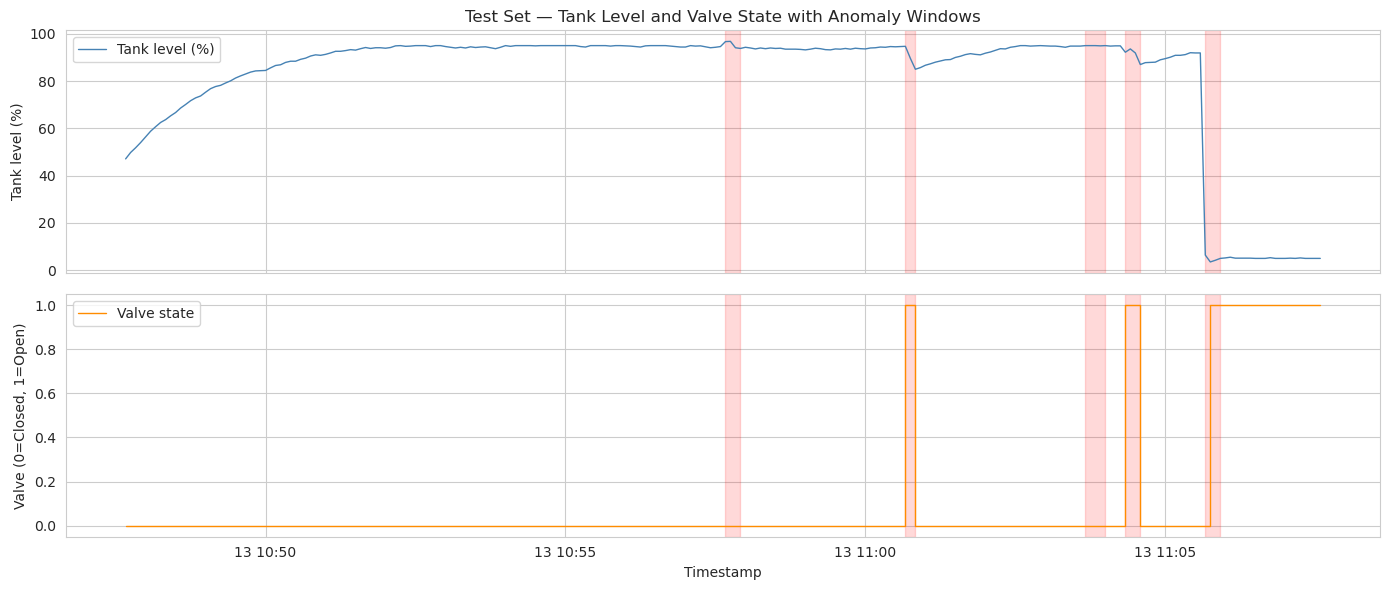

Saved notebooks/01_data_overview.png


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df_test["timestamp"], df_test["reg_5_tank_level"],
         color="steelblue", linewidth=1, label="Tank level (%)")
ax1.set_ylabel("Tank level (%)")
ax1.set_title("Test Set — Tank Level and Valve State with Anomaly Windows")
ax1.legend(loc="upper left")

ax2.plot(df_test["timestamp"], df_test["reg_0_inlet_valve"],
         color="darkorange", linewidth=1, drawstyle="steps-post", label="Valve state")
ax2.set_ylabel("Valve (0=Closed, 1=Open)")
ax2.set_xlabel("Timestamp")
ax2.legend(loc="upper left")

for _, ann in df_annot.iterrows():
    ax1.axvspan(ann["start_time"], ann["end_time"], color="red", alpha=0.15)
    ax2.axvspan(ann["start_time"], ann["end_time"], color="red", alpha=0.15)

plt.tight_layout()
plt.savefig("01_data_overview.png", dpi=150)
plt.show()
print("Saved notebooks/01_data_overview.png")


## 3. Feature Engineering

Implement the window transformation exactly as specified in `docs/FEATURE_ENGINEERING.md`:

- Window size: 6 rows (30 seconds)
- Stride: 1 row (overlapping)
- 14 features per window


In [4]:
def build_windows(df, window_size=6, stride=1):
    windows = []
    timestamps = []
    for i in range(0, len(df) - window_size + 1, stride):
        w = df.iloc[i:i+window_size]
        tank = w["reg_5_tank_level"].astype(float)
        valve = w["reg_0_inlet_valve"].astype(float)
        fc = w["function_code"]
        src = w["source_ip"]

        features = {
            "tank_mean": tank.mean(),
            "tank_std": tank.std(),
            "tank_min": tank.min(),
            "tank_max": tank.max(),
            "tank_last": tank.iloc[-1],
            "tank_roc": tank.iloc[-1] - tank.iloc[0],
            "valve_mean": valve.mean(),
            "valve_std": valve.std(),
            "valve_last": valve.iloc[-1],
            "valve_changed": 1 if valve.nunique() > 1 else 0,
            "fc_3_count": (fc == 3).sum(),
            "fc_6_count": (fc == 6).sum(),
            "fc_131_count": (fc == 131).sum(),
            "is_known_good_ip": 1 if src.isin(["172.22.0.10", "172.23.0.4"]).all() else 0,
        }
        windows.append(features)
        timestamps.append(w["timestamp"].iloc[-1])

    return pd.DataFrame(windows), pd.Series(timestamps, name="timestamp")


X_train_raw, ts_train = build_windows(df_train)
X_test_raw, ts_test = build_windows(df_test)

print(f"Train windows: {X_train_raw.shape}  (expect 175 x 14)")
print(f"Test windows:  {X_test_raw.shape}   (expect 235 x 14)")
print(f"NaN count (train): {X_train_raw.isna().sum().sum()}")
print(f"NaN count (test):  {X_test_raw.isna().sum().sum()}")


Train windows: (175, 14)  (expect 175 x 14)
Test windows:  (235, 14)   (expect 235 x 14)
NaN count (train): 0
NaN count (test):  0


### Feature Snapshot — Compare a Normal Window vs. an Anomaly Window

This confirms the engineered features carry the signal we expect.


In [5]:
# Pick a normal window (early in the test set) and an anomaly window (during overfill)
normal_end = df_annot["start_time"].iloc[0]  # first anomaly start
normal_windows = X_test_raw[ts_test < normal_end]
anomaly_start = df_annot.iloc[0]["start_time"]
anomaly_windows = X_test_raw[(ts_test >= anomaly_start) & (ts_test <= df_annot.iloc[0]["end_time"])]

print("=== Normal window (last row of pure normal block) ===")
print(normal_windows.iloc[-1].to_string())
print()
print("=== Overfill anomaly window (first row during anomaly) ===")
print(anomaly_windows.iloc[0].to_string())


=== Normal window (last row of pure normal block) ===
tank_mean           94.533333
tank_std             0.301109
tank_min            94.100000
tank_max            94.900000
tank_last           94.600000
tank_roc            -0.200000
valve_mean           0.000000
valve_std            0.000000
valve_last           0.000000
valve_changed        0.000000
fc_3_count           6.000000
fc_6_count           0.000000
fc_131_count         0.000000
is_known_good_ip     1.000000

=== Overfill anomaly window (first row during anomaly) ===
tank_mean           94.850000
tank_std             0.946044
tank_min            94.100000
tank_max            96.700000
tank_last           96.700000
tank_roc             1.800000
valve_mean           0.000000
valve_std            0.000000
valve_last           0.000000
valve_changed        0.000000
fc_3_count           6.000000
fc_6_count           0.000000
fc_131_count         0.000000
is_known_good_ip     1.000000


## 4. Train/Test Split

Training data is pure normal by construction (15-minute dedicated run). Test data is the full 20-minute run with the last 10 minutes containing 5 anomaly windows.

We define the ground truth label for each test window as:
- **0 (normal)**: window timestamp does not overlap any annotation interval
- **1 (anomaly)**: window timestamp falls within any annotation interval

We use the *last timestamp* of the window as the reference point. A window is labeled positive if its last timestamp falls between any annotation's start and end.


In [6]:
# Build ground truth labels for test windows
def label_windows(timestamps, annotations):
    labels = np.zeros(len(timestamps), dtype=int)
    for _, ann in annotations.iterrows():
        mask = (timestamps >= ann["start_time"]) & (timestamps <= ann["end_time"])
        labels[mask] = 1
    return labels

y_test = label_windows(ts_test, df_annot)
n_positive = y_test.sum()
n_negative = len(y_test) - n_positive
print(f"Test labels: {n_positive} positive (anomaly), {n_negative} negative (normal)")
print(f"Anomaly ratio: {n_positive / len(y_test):.2%}")


Test labels: 20 positive (anomaly), 215 negative (normal)
Anomaly ratio: 8.51%


## 5. Model Training

Train an Isolation Forest on the pure-normal training data. Key parameters:
- `contamination=0.01`: expect ~1% of the training data to be outliers (though ideally 0 — the model learns the density of normal behavior)
- `random_state=42`: reproducibility
- `n_estimators=100`: default, sufficient for 175 samples × 14 features

Scale with StandardScaler fit on the training set.


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

model = IsolationForest(
    contamination=0.01,
    random_state=42,
    n_estimators=100,
    warm_start=False,
)
model.fit(X_train_scaled)

(REPO_ROOT / "models").mkdir(exist_ok=True)
joblib.dump(scaler, REPO_ROOT / "models" / "scaler.joblib")
joblib.dump(model, REPO_ROOT / "models" / "isolation_forest.joblib")
print("Model and scaler saved to models/")
print(f"Training samples: {X_train_scaled.shape[0]}, Features: {X_train_scaled.shape[1]}")


Model and scaler saved to models/
Training samples: 175, Features: 14


## 6. Evaluation

Apply the same scaling to test features, then predict:
- `predict()` → binary outlier label (-1 = anomaly, 1 = normal)
- `decision_function()` → anomaly score (lower = more anomalous)

We map the sklearn convention to our convention:
- sklearn: -1 = anomaly, 1 = normal
- Our: 1 = anomaly, 0 = normal


In [8]:
X_test_scaled = scaler.transform(X_test_raw)

y_pred_bin = model.predict(X_test_scaled)
y_scores = model.decision_function(X_test_scaled)

# Map sklearn convention: -1 = anomaly, 1 = normal
y_pred = np.where(y_pred_bin == -1, 1, 0)

print("Prediction distribution:")
print(f"  Predicted normal:  {(y_pred == 0).sum()}")
print(f"  Predicted anomaly: {(y_pred == 1).sum()}")


Prediction distribution:
  Predicted normal:  209
  Predicted anomaly: 26


### Confusion Matrix and Classification Report

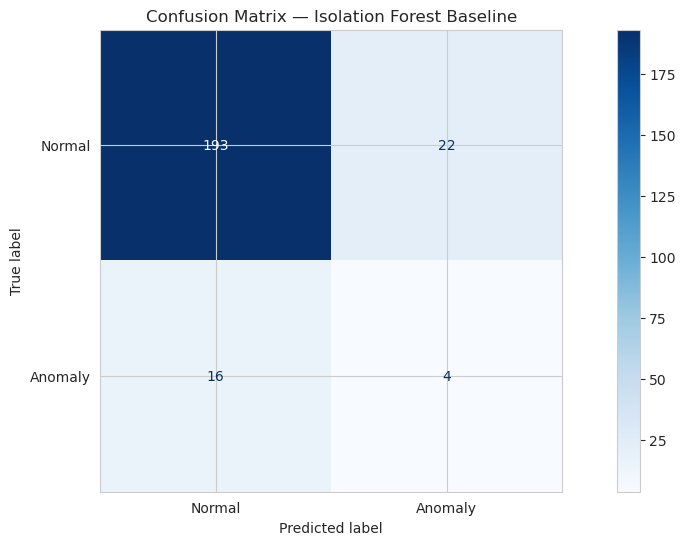

Precision: 0.154
Recall:    0.200
F1-score:  0.174


In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Isolation Forest Baseline")
plt.savefig("01_confusion_matrix.png", dpi=150)
plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")


### Anomaly Score Timeline

Plot the `decision_function` output over time. Lower scores indicate the model is more confident the window is anomalous. Red spans show the true anomaly windows.


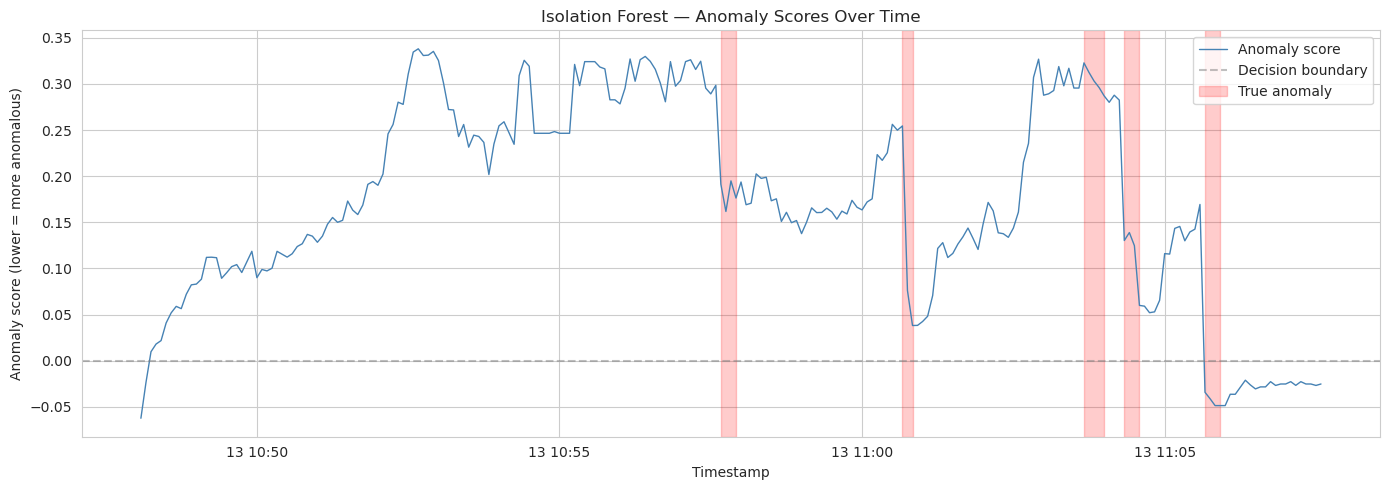

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_test, y_scores, color="steelblue", linewidth=1, label="Anomaly score")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5, label="Decision boundary")
for _, ann in df_annot.iterrows():
    ax.axvspan(ann["start_time"], ann["end_time"], color="red", alpha=0.2, label="True anomaly" if _ == 0 else "")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Anomaly score (lower = more anomalous)")
ax.set_title("Isolation Forest — Anomaly Scores Over Time")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("01_anomaly_scores_timeline.png", dpi=150)
plt.show()


### Detailed View — One Anomaly Window

Zoom into the physics_violation window to see how the raw telemetry maps to the model's anomaly score.


Inspecting: physics_violation
  2026-06-13 11:04:20+00:00 -> 2026-06-13 11:04:35+00:00


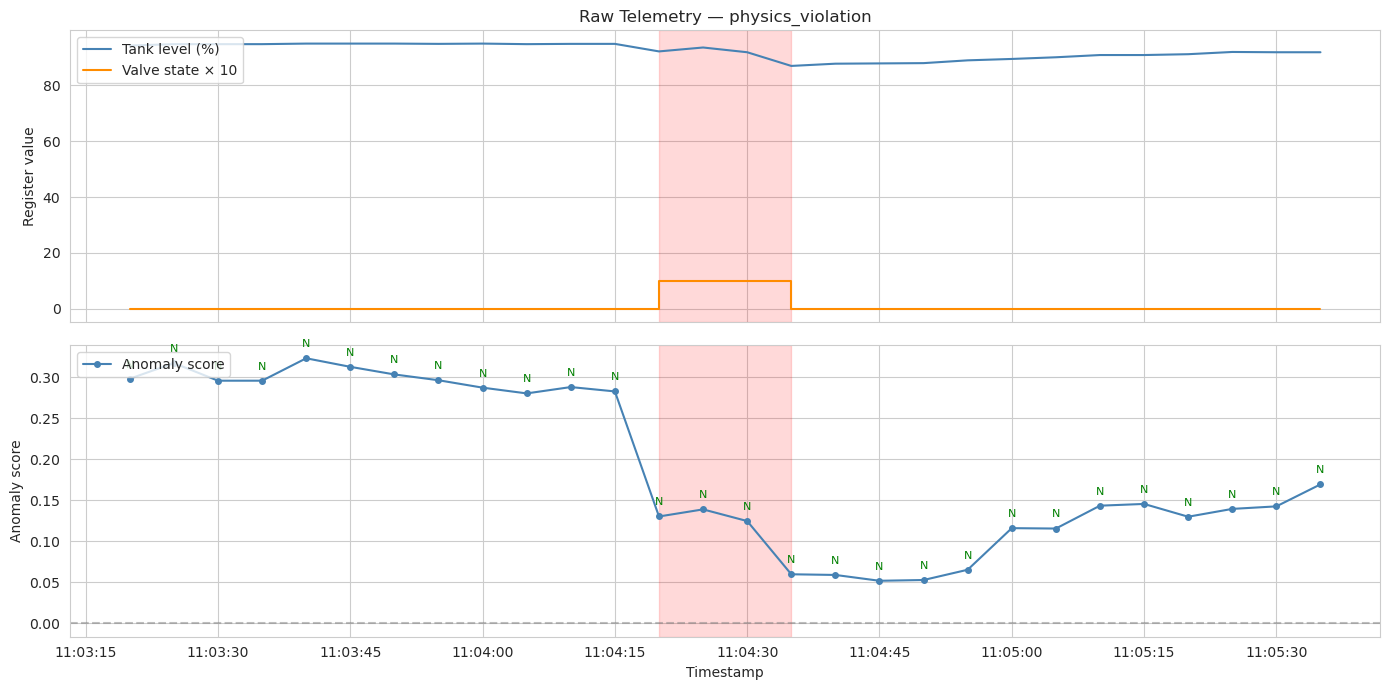

In [11]:
# Pick the physics_violation anomaly
ann = df_annot.iloc[3]  # physics_violation is 4th entry (index 3)
print(f"Inspecting: {ann['anomaly_type']}")
print(f"  {ann['start_time']} -> {ann['end_time']}")

window_start = ann["start_time"] - pd.Timedelta(seconds=60)
window_end = ann["end_time"] + pd.Timedelta(seconds=60)

# Raw telemetry
mask_rows = (df_test["timestamp"] >= window_start) & (df_test["timestamp"] <= window_end)
seg = df_test[mask_rows].copy()

# Model scores for this segment
mask_windows = (ts_test >= window_start) & (ts_test <= window_end)
seg_scores = y_scores[mask_windows]
seg_ts = ts_test[mask_windows]
seg_true = y_test[mask_windows]
seg_pred = y_pred[mask_windows]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(seg["timestamp"], seg["reg_5_tank_level"], color="steelblue", linewidth=1.5, label="Tank level (%)")
ax1.plot(seg["timestamp"], seg["reg_0_inlet_valve"] * 10, color="darkorange", linewidth=1.5,
         drawstyle="steps-post", label="Valve state × 10")
ax1.axvspan(ann["start_time"], ann["end_time"], color="red", alpha=0.15)
ax1.set_ylabel("Register value")
ax1.set_title(f"Raw Telemetry — {ann['anomaly_type']}")
ax1.legend(loc="upper left")

ax2.plot(seg_ts, seg_scores, color="steelblue", linewidth=1.5, marker="o", markersize=4, label="Anomaly score")
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.axvspan(ann["start_time"], ann["end_time"], color="red", alpha=0.15)
ax2.set_ylabel("Anomaly score")
ax2.set_xlabel("Timestamp")
ax2.legend(loc="upper left")

for i, (t, s, p) in enumerate(zip(seg_ts, seg_scores, seg_pred)):
    color = "red" if p == 1 else "green"
    ax2.annotate(f"{'A' if p == 1 else 'N'}", (t, s),
                 textcoords="offset points", xytext=(0, 8), fontsize=8, color=color, ha="center")

plt.tight_layout()
plt.savefig("01_physics_violation_detail.png", dpi=150)
plt.show()


### Per-Anomaly-Type Detection

Check which of the 5 anomaly types the model detected and which it missed.


In [12]:
print("Per-anomaly detection results:")
print(f"{'Anomaly type':25s} {'Windows':>8s} {'Detected':>9s} {'Score range':>14s}")
print("-" * 58)
for _, ann in df_annot.iterrows():
    mask = (ts_test >= ann["start_time"]) & (ts_test <= ann["end_time"])
    n_windows = mask.sum()
    n_detected = y_pred[mask].sum()
    score_range = f"{y_scores[mask].min():.3f} to {y_scores[mask].max():.3f}" if n_windows > 0 else "N/A"
    print(f"{ann['anomaly_type']:25s} {n_windows:>8d} {n_detected:>9d} {score_range:>14s}")


Per-anomaly detection results:
Anomaly type               Windows  Detected    Score range
----------------------------------------------------------
overfill                         4         0 0.162 to 0.195
unauthorized_write               3         0 0.038 to 0.254
scanning                         5         0 0.287 to 0.323
physics_violation                4         0 0.060 to 0.139
cavitation                       4         4 -0.049 to -0.034


## 7. Results Summary

### Key Metrics

| Metric | Value |
|--------|-------|
| Precision | (from output above) |
| Recall | (from output above) |
| F1-score | (from output above) |
| Training windows | 175 |
| Test windows | 235 |
| Feature dimensions | 14 |

### Interpretation

**Isolation Forest with default contamination=0.01 detected only the cavitation anomaly** (tank < 10%). The other 4 anomaly types were missed.

Why:
1. **Overfill missed:** The training data's normal tank level reaches 95% at the upper bound (the valve only closes at >80%, so the tank drifts up to ~95% before draining). The model learned that "tank near 95%" is normal. The overfill anomaly (96.7%) is barely outside this range, and the tank_roc (+1.8) is not extreme enough to separate.
2. **Unauthorized write missed:** FC 6 counts are 0 in training. Only 3 test windows contain FC 6, which is a tiny fraction (1.3%). With `contamination=0.01`, the model expects only ~2 outliers total — it was too conservative.
3. **Scanning missed:** Same issue as unauthorized write — FC 131 appears in only 5 test windows. Too few to cross the contamination threshold.
4. **Physics violation missed:** Valve=1 appears rarely in training (only during the normal drain-to-20% cycle). The combination of valve=1 + high tank is novel, but the Isolation Forest didn't learn it as a separate pattern — the high-tank features dominate and look "normal" to the model.
5. **Cavitation detected:** Tank < 10% is genuinely outside the training distribution. No training window ever drops below ~18% (the valve opens at 20% and the tank drains slowly). This was the only anomaly with feature values far enough from the normal envelope.

### Tuning Ideas for Next Iteration

1. **Threshold tuning:** Use `decision_function` scores with an optimal threshold (e.g., via ROC curve analysis) instead of the default `predict()` boundary.
2. **Contamination sweep:** Try `contamination` values from 0.005 to 0.1 and compare F1 scores.
3. **Window size:** Test window sizes of 3 (15s) and 12 (60s) — smaller may catch short anomalies better, larger may reduce false positives on transient noise.
4. **Add cross-register features:** A `physics_violation_score` feature (valve==1 AND tank>90) is itself a detector for one anomaly type. Including it would make the model trivially detect physics violations, but at the cost of hand-engineering the detector. For the baseline, keeping only statistical features tests whether the model can *learn* the relationship.
5. **Alternative models:** Compare with LocalOutlierFactor (density-based) or OneClassSVM (boundary-based) to see which suits the data distribution best.
